# Telecom churn prediction EDA


## 1. Setup & load data


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

In [24]:
client = pd.read_csv("./telecom/Client.csv")
record = pd.read_csv("./telecom/Record.csv")

print("Client shape:", client.shape)
print("Record shape:", record.shape)
print("Shared columns:", set(client.columns) & set(record.columns))

Client shape: (100000, 50)
Record shape: (100000, 51)
Shared columns: {'Customer_ID'}


## 2. Relationship between the two tables

Both files are **one row per customer**. The only shared column is `Customer_ID`, which is a 1:1 join key.


In [25]:
print("Client Customer_ID unique:", client["Customer_ID"].nunique(),"| duplicates:", client["Customer_ID"].duplicated().sum())
print("Record Customer_ID unique:", record["Customer_ID"].nunique(),"| duplicates:", record["Customer_ID"].duplicated().sum())

client_ids = set(client["Customer_ID"])
record_ids = set(record["Customer_ID"])
print("Same ID set:", client_ids == record_ids)
print("Only in Client:", len(client_ids - record_ids))
print("Only in Record:", len(record_ids - client_ids))

# Inner join for analysis
df = record.merge(client, on="Customer_ID", how="inner")
print("Merged shape:", df.shape)
df.head()

Client Customer_ID unique: 100000 | duplicates: 0
Record Customer_ID unique: 100000 | duplicates: 0
Same ID set: True
Only in Client: 0
Only in Record: 0
Merged shape: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


## 3. Schema overview

- **Record**: recent mean usage/billing, call quality, `months`, target `churn`
- **Client**: lifetime metrics, demographics, handset / household attributes

With current pandas, text columns may show dtype `str` (not `object`). Treat them as categoricals to encode later.


In [26]:
print("=== Client dtypes ===")
print(client.dtypes.value_counts())
print("\n=== Record dtypes ===")
print(record.dtypes.value_counts())
print("\nClient columns:")
print(list(client.columns))
print("\nRecord columns:")
print(list(record.columns))

=== Client dtypes ===
str        21
float64    21
int64       8
Name: count, dtype: int64

=== Record dtypes ===
float64    48
int64       3
Name: count, dtype: int64

Client columns:
['uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars', 'HHstatin', 'dwllsize', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays', 'Customer_ID']

Record columns:
['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'un

## 4. Missing values

Missingness is much heavier in **Client demographics** than in **Record usage** fields.


Client: 27 columns with >= 0.01% missing
                  % missing
numbcars              49.37
dwllsize              38.31
HHstatin              37.92
ownrent               33.71
dwlltype              31.91
lor                   30.19
income                25.44
adults                23.02
infobase              22.08
hnd_webcap            10.19
prizm_social_one       7.39
avg6qty                2.84
avg6mou                2.84
avg6rev                2.84
truck                  1.73
marital                1.73
rv                     1.73
kid0_2                 1.73
kid16_17               1.73
kid3_5                 1.73
Record: 11 columns with >= 0.01% missing
             % missing
change_mou        0.89
change_rev        0.89
rev_Mean          0.36
totmrc_Mean       0.36
mou_Mean          0.36
da_Mean           0.36
ovrmou_Mean       0.36
vceovr_Mean       0.36
ovrrev_Mean       0.36
roam_Mean         0.36
datovr_Mean       0.36


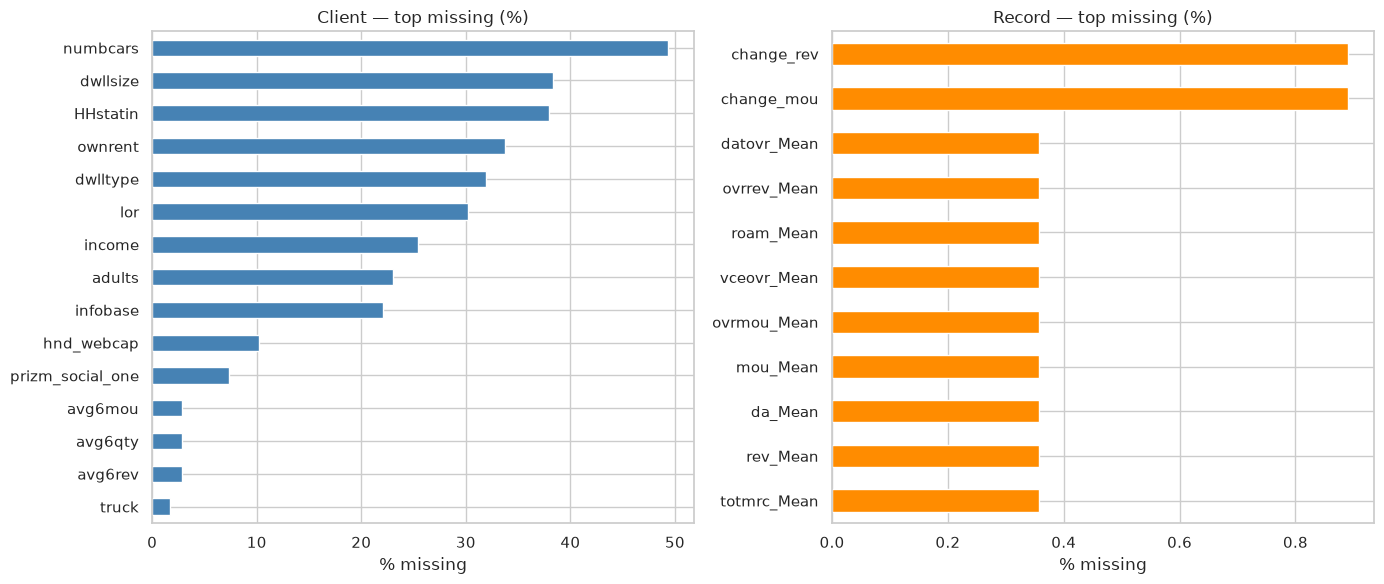

In [27]:
def missing_summary(frame, name, top_n=20, min_pct=0.01):
    miss = frame.isna().mean().mul(100).sort_values(ascending=False)
    miss = miss[miss >= min_pct]
    print(f"{name}: {len(miss)} columns with >= {min_pct}% missing")
    print(miss.head(top_n).round(2).to_frame("% missing"))
    return miss

miss_client = missing_summary(client, "Client")
miss_record = missing_summary(record, "Record")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
miss_client.head(15).sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Client — top missing (%)")
axes[0].set_xlabel("% missing")
miss_record.head(15).sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Record — top missing (%)")
axes[1].set_xlabel("% missing")
plt.tight_layout()
plt.show()

## 5. Target variable: `churn`

`churn` = 1 if the customer churned 31–60 days after the observation date.


churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.5044
1    0.4956
Name: proportion, dtype: float64


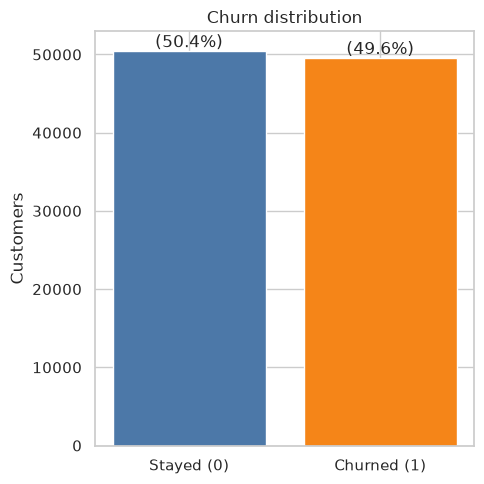

In [28]:
print(df["churn"].value_counts())
print()
print(df["churn"].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(5, 5))
counts = df["churn"].value_counts().sort_index()
ax.bar(["Stayed (0)", "Churned (1)"], counts.values, color=["#4C78A8", "#F58518"]) # pyright: ignore[reportArgumentType]
ax.set_ylabel("Customers")
ax.set_title("Churn distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"({v/len(df):.1%})", ha="center")
plt.tight_layout()
plt.show()

Churn is nearly **50/50**, so accuracy is a reasonable evaluation metric for modeling later.

## 6. Numeric summaries

Watch for quality issues in the ranges: negative `eqpdays`, slight negative revenue/MRC (credits), and heavy tails on `change_mou` / `change_rev`.


In [29]:
# Key Record metrics
record_key = [
    "rev_Mean", "mou_Mean", "totmrc_Mean", "ovrmou_Mean", "ovrrev_Mean",
    "change_mou", "change_rev", "drop_vce_Mean", "custcare_Mean",
    "months", "churn"
]
print("=== Record / outcome metrics ===")
print(df[record_key].describe().T.round(2))

# Key Client metrics
client_key = [
    "totcalls", "totmou", "totrev", "avgrev", "avgmou",
    "avg3mou", "avg6mou", "eqpdays", "phones", "models",
    "hnd_price", "uniqsubs", "actvsubs", "income", "months"
]
print("\n=== Client / profile metrics ===")
print(df[[c for c in client_key if c in df.columns]].describe().T.round(2))

print("\nData-quality flags:")
print(f"- eqpdays < 0: {(df['eqpdays'] < 0).sum()} rows (min={df['eqpdays'].min()})")
print(f"- rev_Mean < 0: {(df['rev_Mean'] < 0).sum()} rows")
print(f"- totmrc_Mean < 0: {(df['totmrc_Mean'] < 0).sum()} rows")

=== Record / outcome metrics ===
                  count    mean     std      min     25%     50%     75%  \
rev_Mean        99643.0   58.72   46.29    -6.17   33.26   48.20   70.75   
mou_Mean        99643.0  513.56  525.17     0.00  150.75  355.50  703.00   
totmrc_Mean     99643.0   46.18   23.62   -26.92   30.00   44.99   59.99   
ovrmou_Mean     99643.0   41.07   97.30     0.00    0.00    2.75   42.00   
ovrrev_Mean     99643.0   13.56   30.50     0.00    0.00    1.00   14.44   
change_mou      99109.0  -13.93  276.09 -3875.00  -87.00   -6.25   63.00   
change_rev      99109.0   -1.02   50.36 -1107.74   -7.36   -0.32    1.64   
drop_vce_Mean  100000.0    5.96    8.95     0.00    0.67    3.00    7.67   
custcare_Mean  100000.0    1.79    5.32     0.00    0.00    0.00    1.67   
months         100000.0   18.83    9.66     6.00   11.00   16.00   24.00   
churn          100000.0    0.50    0.50     0.00    0.00    0.00    1.00   

                    max  
rev_Mean        3843.26  
mo

## 7. Distributions of key usage & billing features


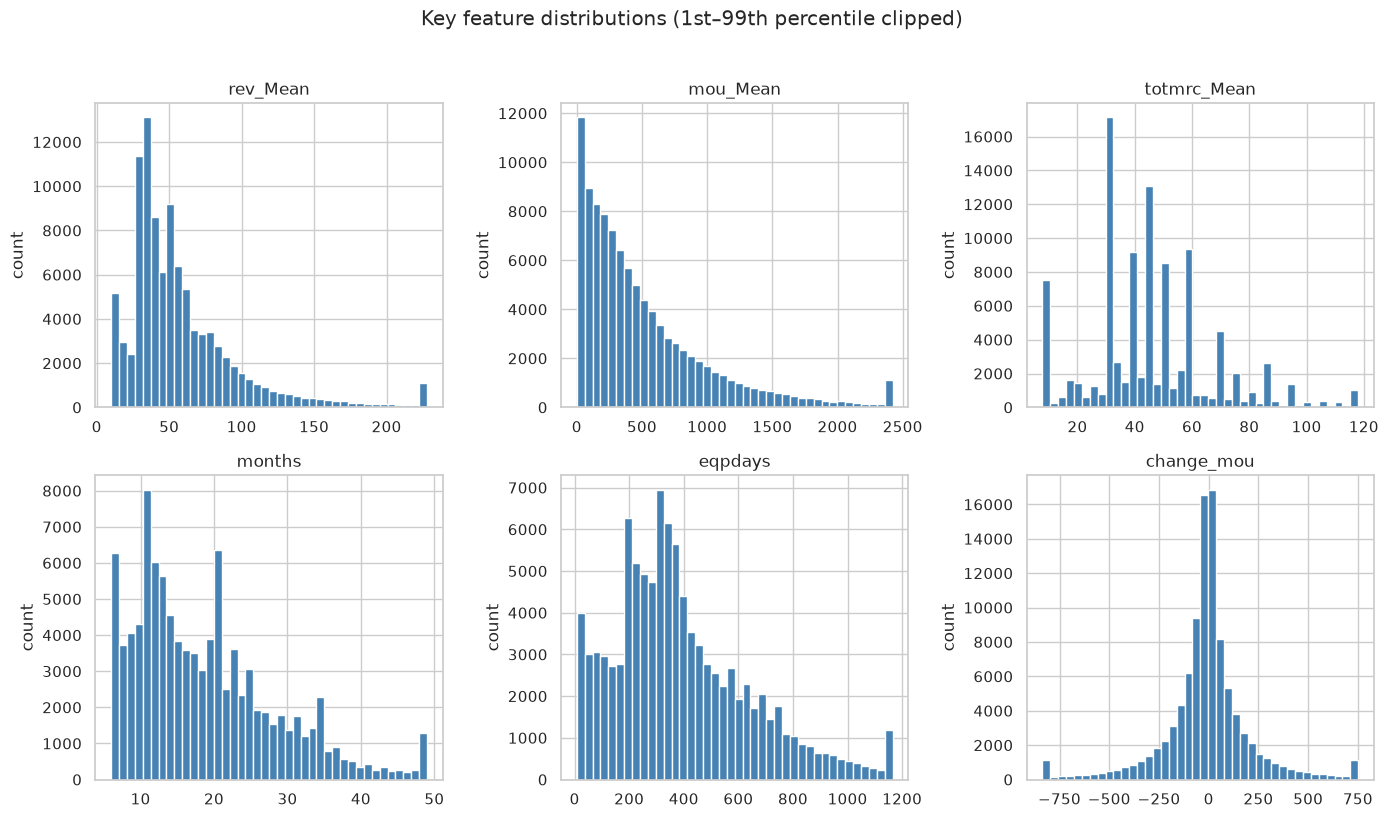

In [30]:
plot_cols = ["rev_Mean", "mou_Mean", "totmrc_Mean", "months", "eqpdays", "change_mou"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    s = df[col].dropna()
    # clip extreme tails for readability
    lo, hi = s.quantile([0.01, 0.99])
    s.clip(lo, hi).hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("count")
plt.suptitle("Key feature distributions (1st–99th percentile clipped)", y=1.02)
plt.tight_layout()
plt.show()

## 8. Churn vs selected features

Compare means and distributions for candidates that often relate to retention.


In [31]:
compare_cols = [
    "eqpdays", "months", "rev_Mean", "mou_Mean", "totmrc_Mean",
    "change_mou", "change_rev", "custcare_Mean", "drop_vce_Mean",
    "ovrmou_Mean", "phones", "hnd_price"
]

summary = (
    df.groupby("churn")[compare_cols]
    .mean()
    .T
    .rename(columns={0: "stayed_mean", 1: "churned_mean"})
)
summary["diff (churned - stayed)"] = summary["churned_mean"] - summary["stayed_mean"]
# Avoid % of stayed mean: it blows up when the base is near 0 or negative (e.g. change_mou).
summary = summary.sort_values("diff (churned - stayed)", key=lambda s: s.abs(), ascending=False)
print(summary.round(2))

churn          stayed_mean  churned_mean  diff (churned - stayed)
mou_Mean            543.21        483.31                   -59.90
eqpdays             363.28        421.09                    57.81
change_mou           -5.34        -22.76                   -17.41
hnd_price           108.13         95.54                   -12.59
ovrmou_Mean          39.17         43.01                     3.84
totmrc_Mean          47.78         44.54                    -3.24
rev_Mean             59.22         58.21                    -1.01
change_rev           -1.41         -0.62                     0.79
months               18.63         19.04                     0.41
custcare_Mean         1.98          1.60                    -0.39
drop_vce_Mean         6.09          5.82                    -0.27
phones                1.84          1.73                    -0.10


- Largest gaps: churners tend to have older handsets (eqpdays)
- ower recent MOU, and a sharper drop in minutes (more negative change_mou)


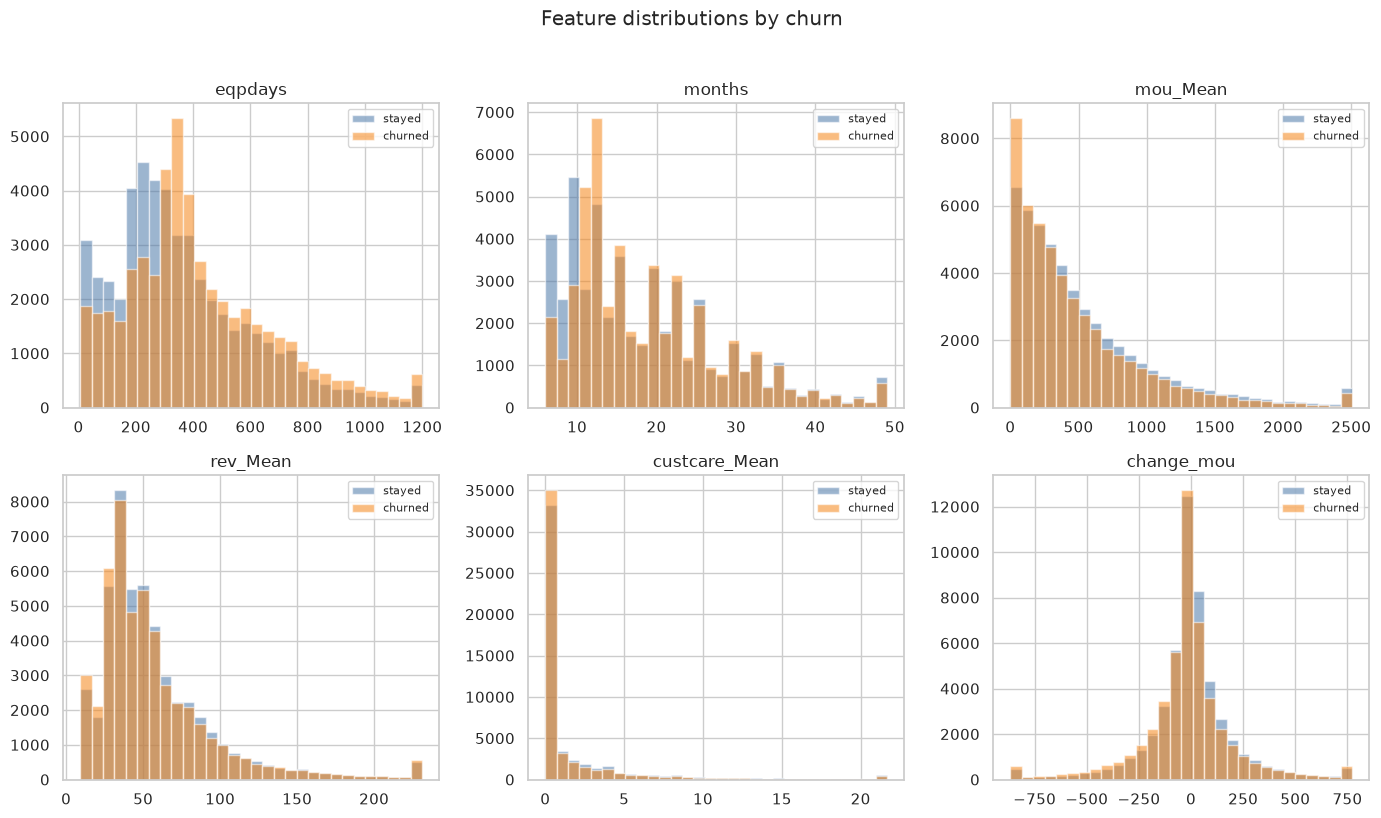

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
feat_plots = ["eqpdays", "months", "mou_Mean", "rev_Mean", "custcare_Mean", "change_mou"]
for ax, col in zip(axes.ravel(), feat_plots):
    stayed = df.loc[df["churn"] == 0, col].dropna()
    churned = df.loc[df["churn"] == 1, col].dropna()
    lo = min(stayed.quantile(0.01), churned.quantile(0.01))
    hi = max(stayed.quantile(0.99), churned.quantile(0.99))
    ax.hist(stayed.clip(lo, hi), bins=30, alpha=0.55, label="stayed", color="#4C78A8")
    ax.hist(churned.clip(lo, hi), bins=30, alpha=0.55, label="churned", color="#F58518")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Feature distributions by churn", y=1.02)
plt.tight_layout()
plt.show()

## 9. Categorical / segment views


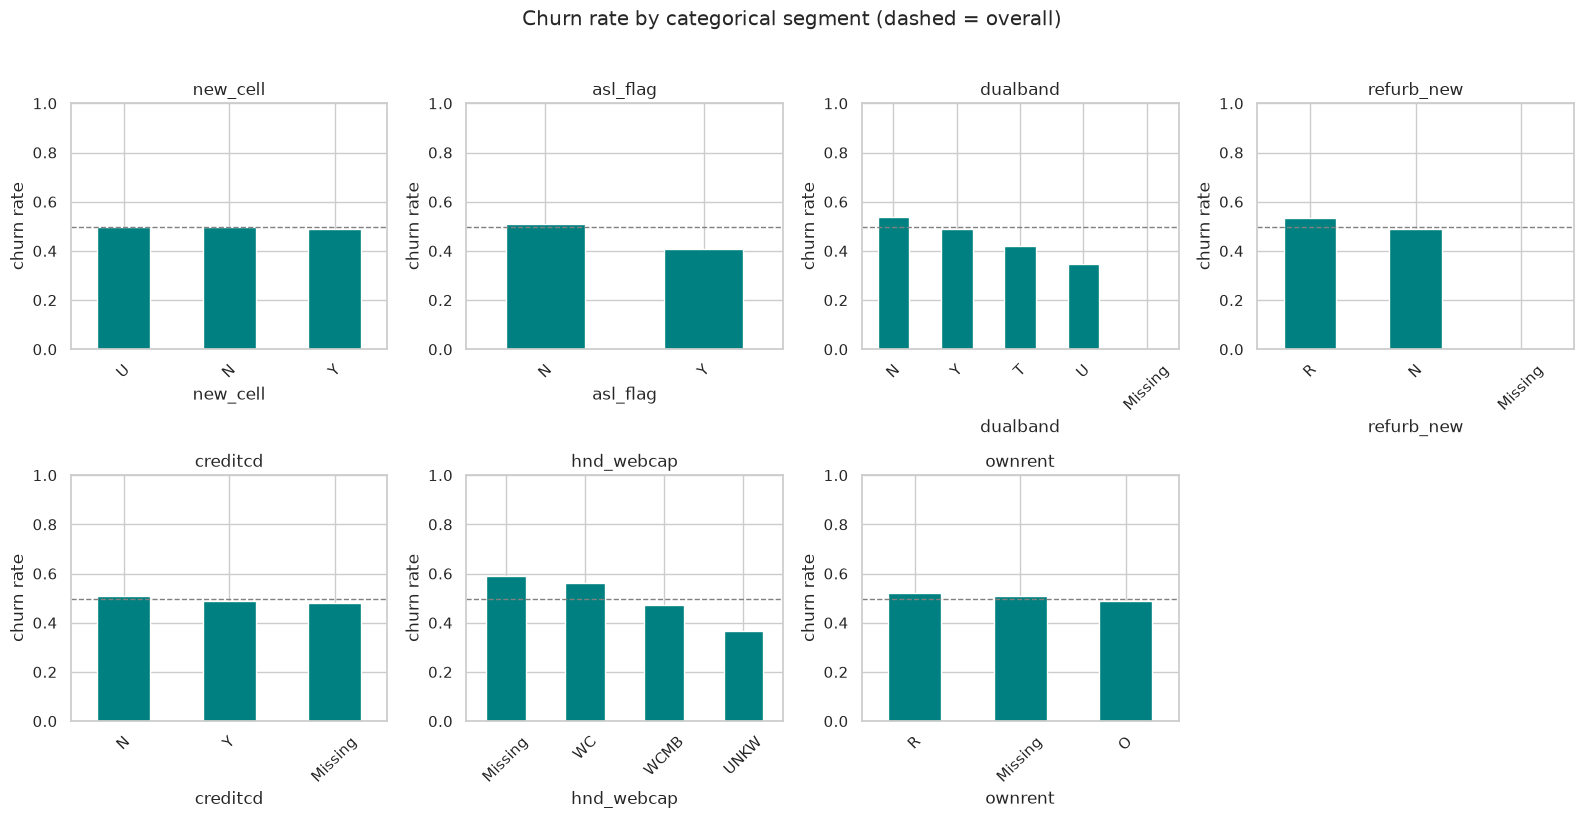

In [33]:
cat_cols = ["new_cell", "asl_flag", "dualband", "refurb_new", "creditcd", "hnd_webcap", "ownrent"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    tmp = df[[col, "churn"]].copy()
    tmp[col] = tmp[col].astype("string").fillna("Missing")
    rates = tmp.groupby(col)["churn"].mean().sort_values(ascending=False)
    rates.plot.bar(ax=ax, color="teal")
    ax.axhline(df["churn"].mean(), color="gray", ls="--", lw=1, label="overall")
    ax.set_ylim(0, 1)
    ax.set_ylabel("churn rate")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(cat_cols):]:
    ax.axis("off")
plt.suptitle("Churn rate by categorical segment (dashed = overall)", y=1.02)
plt.tight_layout()
plt.show()

,n,churn_rate
area,,
NEW YORK CITY AREA,11098,0.500
LOS ANGELES AREA,6636,0.498
DC/MARYLAND/VIRGINIA AREA,6567,0.460
MIDWEST AREA,6346,0.459
SOUTHWEST AREA,6187,0.510
ATLANTIC SOUTH AREA,6132,0.490
CALIFORNIA NORTH AREA,5913,0.521
NEW ENGLAND AREA,5452,0.517
DALLAS AREA,5426,0.487


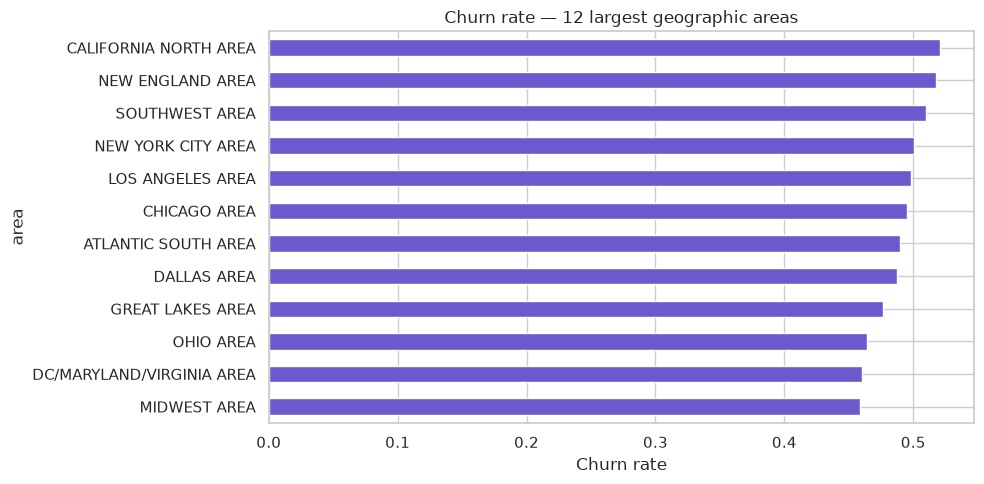

In [34]:
# Geographic churn rates (top areas by volume)
area_stats = (
    df.groupby("area", dropna=False)
    .agg(n=("churn", "size"), churn_rate=("churn", "mean"))
    .sort_values("n", ascending=False)
    .head(12)
)
display(area_stats.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
area_stats["churn_rate"].sort_values().plot.barh(ax=ax, color="slateblue")
ax.set_xlabel("Churn rate")
ax.set_title("Churn rate — 12 largest geographic areas")
plt.tight_layout()
plt.show()

## 10. Correlations (numeric subset)

Look for redundancy among revenue / usage families and association with churn.


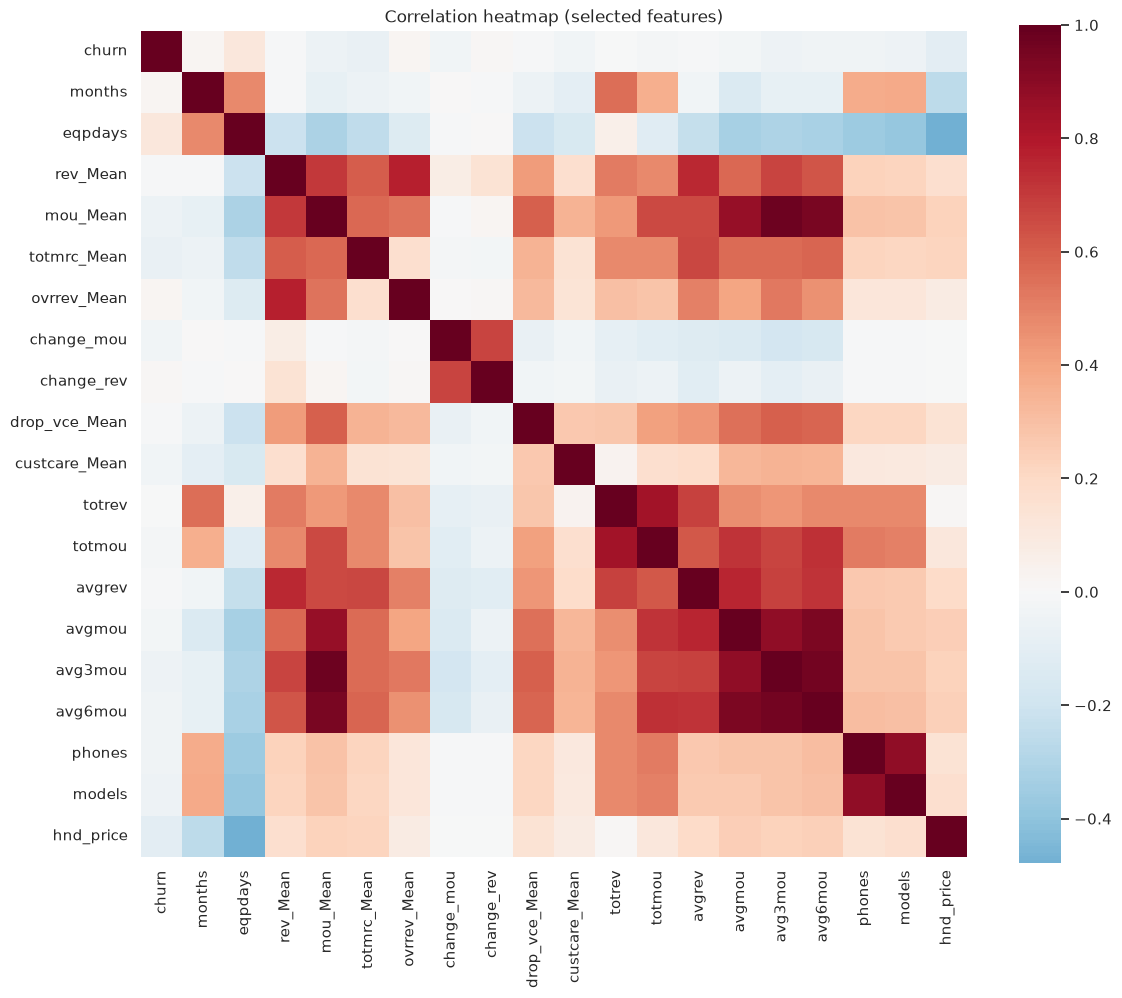

Correlations with churn (sorted by |r|):
               corr_with_churn
eqpdays                  0.113
hnd_price               -0.103
totmrc_Mean             -0.069
mou_Mean                -0.057
avg3mou                 -0.050
models                  -0.045
avg6mou                 -0.044
phones                  -0.039
custcare_Mean           -0.036
change_mou              -0.032
avgmou                  -0.024
ovrrev_Mean              0.024
months                   0.021
totmou                  -0.017
drop_vce_Mean           -0.015
rev_Mean                -0.011
avgrev                  -0.009
change_rev               0.008
totrev                  -0.003

Linear associations with churn are weak (|r| max ≈ 0.11).
That supports a tree model later — non-linear / interaction effects matter more than single-feature correlations.


In [36]:
corr_cols = [
    "churn", "months", "eqpdays",
    "rev_Mean", "mou_Mean", "totmrc_Mean", "ovrrev_Mean",
    "change_mou", "change_rev",
    "drop_vce_Mean", "custcare_Mean",
    "totrev", "totmou", "avgrev", "avgmou", "avg3mou", "avg6mou",
    "phones", "models", "hnd_price"
]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, square=True, ax=ax)
ax.set_title("Correlation heatmap (selected features)")
plt.tight_layout()
plt.show()

churn_corr = (
    corr["churn"].drop("churn")
    .reindex(corr["churn"].drop("churn").abs().sort_values(ascending=False).index)
)
print("Correlations with churn (sorted by |r|):")
print(churn_corr.round(3).to_frame("corr_with_churn"))
print("\nLinear associations with churn are weak (|r| max ≈ 0.11).")
print("That supports a tree model later — non-linear / interaction effects matter more than single-feature correlations.")

## 11. Pairwise view: revenue, usage, tenure, equipment


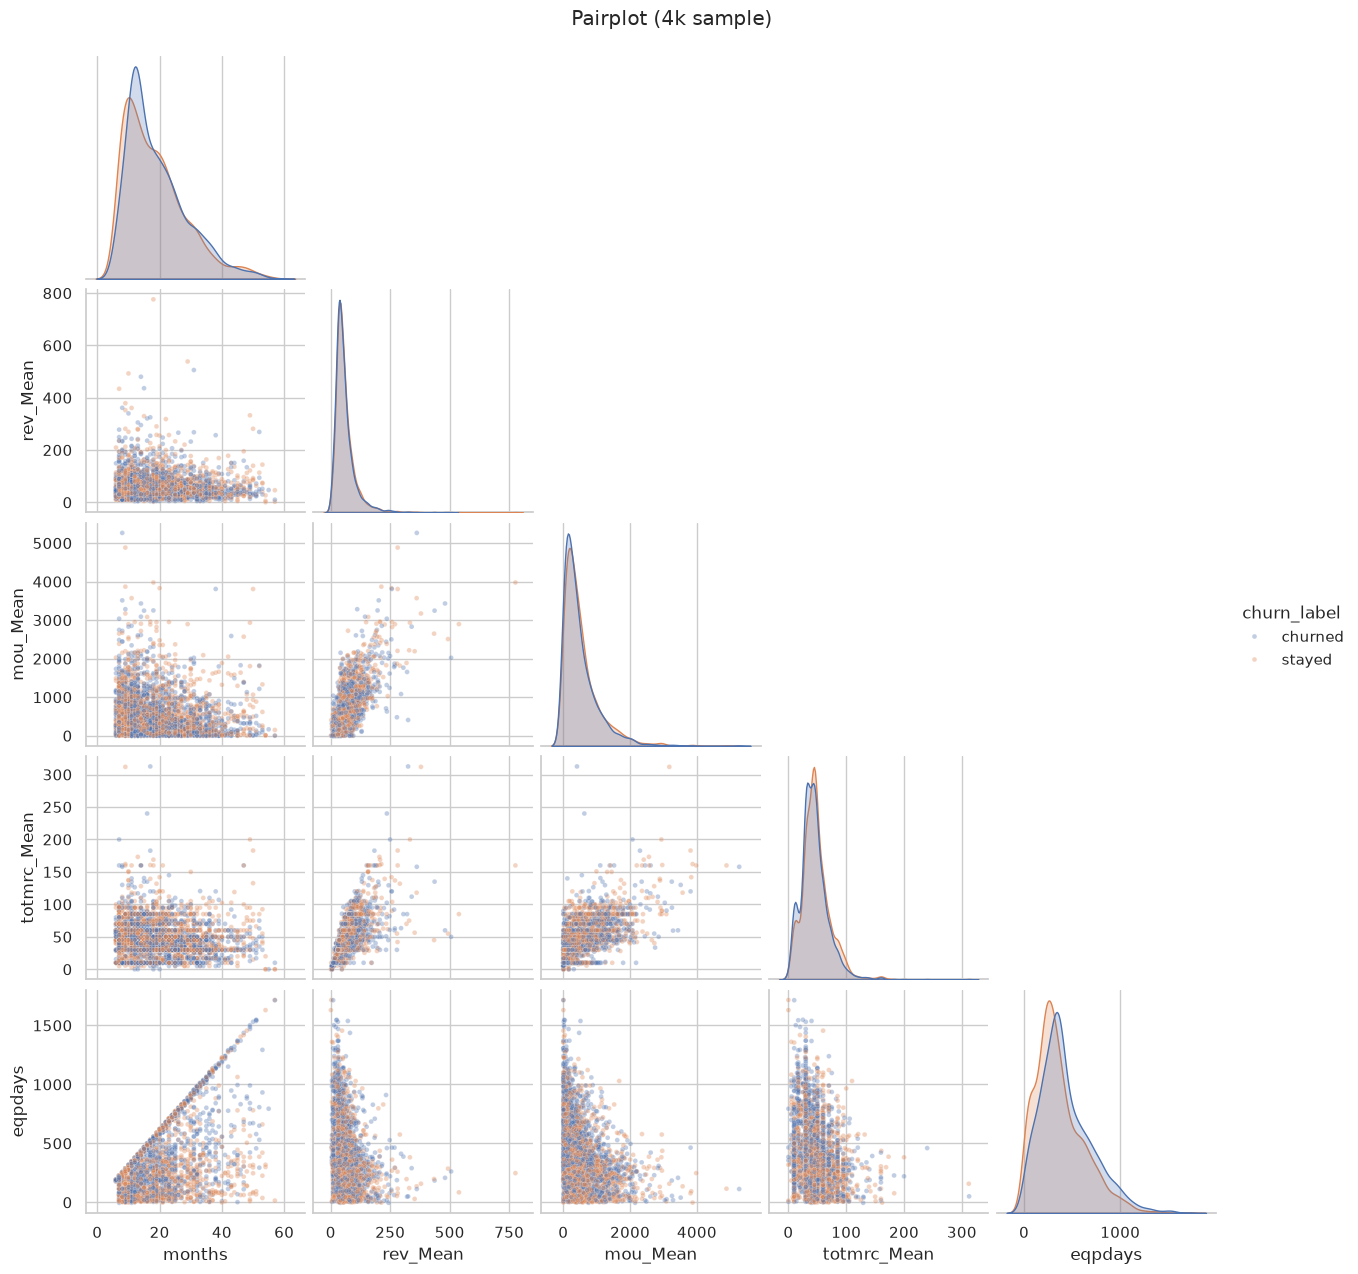

In [ ]:
pair_df = df[["months", "rev_Mean", "mou_Mean", "totmrc_Mean", "eqpdays", "churn"]].dropna().copy()
# sample for speed
pair_df = pair_df.sample(n=min(4000, len(pair_df)), random_state=42)
pair_df["churn_label"] = pair_df["churn"].map({0: "stayed", 1: "churned"})

sns.pairplot(
    pair_df,
    vars=["months", "rev_Mean", "mou_Mean", "totmrc_Mean", "eqpdays"],
    hue="churn_label",
    corner=True,
    plot_kws={"alpha": 0.35, "s": 12},
    diag_kws={"common_norm": False},
)
plt.suptitle("Pairplot (4k sample)", y=1.02)
plt.show()

## 12. Lifetime (Client) vs recent (Record) metrics

Client lifetime averages should align directionally with Record mean monthly usage — useful sanity check of the join.


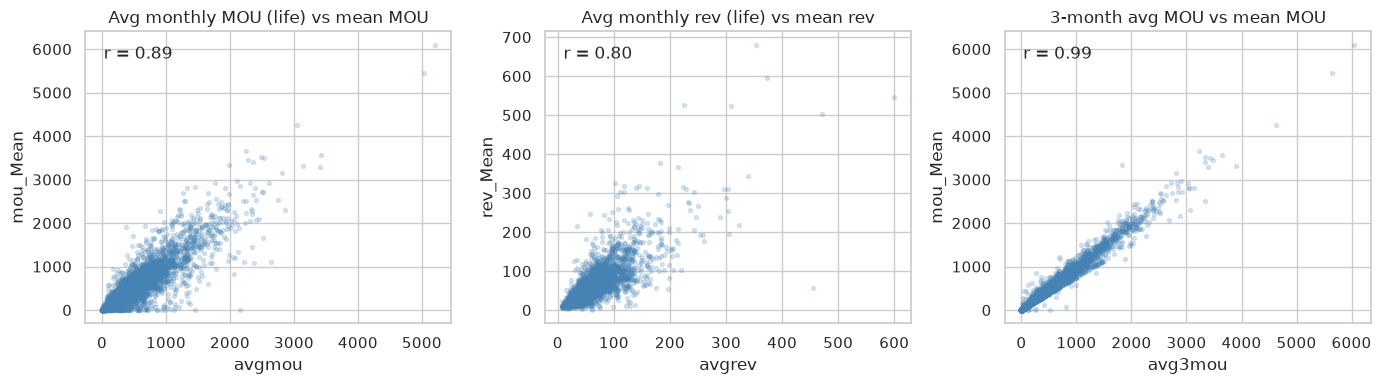

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [
    ("avgmou", "mou_Mean", "Avg monthly MOU (life) vs mean MOU"),
    ("avgrev", "rev_Mean", "Avg monthly rev (life) vs mean rev"),
    ("avg3mou", "mou_Mean", "3-month avg MOU vs mean MOU"),
]
sample = df.sample(n=5000, random_state=0)
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(sample[x], sample[y], alpha=0.2, s=8, color="steelblue")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
    r = sample[[x, y]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes, va="top")
plt.tight_layout()
plt.show()